# Paired A/B Model Comparison via Pólya–Gamma Gibbs Sampling

This notebook implements **exact** Bayesian logistic regression for paired binary scores
using the **Pólya–Gamma data-augmentation** scheme (Polson, Scott & Windle, 2013).

### Use simulated data

In [32]:
import numpy as np
from pathlib import Path

from bayesprop.resources.bayes_paired_laplace import PairedBayesPropTest, _format_bf
from bayesprop.resources.bayes_paired_pg import PairedBayesPropTestPG
from bayesprop.utils.utils import simulate_paired_scores

IMG_DIR = Path("../../docs/mkdocs/docs/images/paired-gibbs")
IMG_DIR.mkdir(parents=True, exist_ok=True)

# Simulate paired binary data (same DGP as Laplace notebook)
sim = simulate_paired_scores(N=250, delta_A=0.8, sigma_theta=0.0, seed=42)

y_A_sim = sim.y_A
y_B_sim = sim.y_B

mu = sim.true_params.mu
delta_A = sim.true_params.delta_A

p_A = 1 / (1 + np.exp(-(mu + delta_A)))
p_B = 1 / (1 + np.exp(-mu))

print(f"True μ   = {mu:.4f}")
print(f"True δ_A = {delta_A:.4f}")
print(f"p_A = logistic(μ + δ_A) = {p_A:.4f}")
print(f"p_B = logistic(μ)       = {p_B:.4f}")
print(f"True Δ = p_A − p_B      = {p_A - p_B:.4f}")

True μ   = 0.0000
True δ_A = 0.8000
p_A = logistic(μ + δ_A) = 0.6900
p_B = logistic(μ)       = 0.5000
True Δ = p_A − p_B      = 0.1900


In [33]:
# Fit PG model using PairedBayesPropTestPG class
# (defaults: n_iter=1000, burn_in=200, n_chains=2 — block-conjugate Gibbs
#  reaches R-hat ≈ 1.00 by ~200 iterations.)
pg_model = PairedBayesPropTestPG(seed=42).fit(y_A_sim, y_B_sim)

s = pg_model.summary
print(f"δ_A posterior mean = {s.delta_A_posterior_mean:+.4f}")
print(f"Mean Δ (prob)  = {s.mean_delta:+.4f}")
print(f"95% CI         = [{s.ci_95.lower:.4f}, {s.ci_95.upper:.4f}]")
print(f"P(A>B)         = {s.p_A_greater_B:.4f}")

# ── Unified decision ─────────────────────────────────────────────────
d_pg = pg_model.decide()
bf_pg = d_pg.bayes_factor
print("\n--- Unified Decision (PG Gibbs) ---")
print(f"  Bayes Factor:  BF₁₀ = {bf_pg.BF_10:.2f}  → {bf_pg.decision}")
print(f"  Posterior Null: P(H₀|D) = {d_pg.posterior_null.p_H0:.4f}  → {d_pg.posterior_null.decision}")
print(f"  ROPE:          {d_pg.rope.decision}  ({d_pg.rope.pct_in_rope:.1%} in ROPE)")

delta_samples = pg_model.delta_A_samples
mu_samples = pg_model.samples[:, 0]

display(pg_model.trace_summary)

δ_A posterior mean = +0.8772
Mean Δ (prob)  = +0.2086
95% CI         = [0.1264, 0.2902]
P(A>B)         = 1.0000

--- Unified Decision (PG Gibbs) ---
  Bayes Factor:  BF₁₀ = 3335592934.76  → Reject H0
  Posterior Null: P(H₀|D) = 0.0000  → Reject H0
  ROPE:          Reject H0 — A practically better  (0.0% in ROPE)


,mean,sd,hdi_3%,hdi_97%,R-hat,ESS
delta_A,0.877166,0.182879,0.535936,1.224447,0.999776,5333.173602
mu,-0.081439,0.124043,-0.315657,0.149626,0.999718,5671.464446


## Compare PG vs Laplace posteriors

In [34]:
# Fit the same data with the Laplace model for comparison
laplace_model = PairedBayesPropTest(seed=42, n_samples=2000).fit(y_A_sim, y_B_sim)

laplace_delta = laplace_model.delta_A_samples
laplace_mu = laplace_model.laplace["mu_samples"]

print("PG Gibbs vs Laplace — posterior summary")
print("=" * 55)
print(f"{'':20} {'PG Gibbs':>15} {'Laplace':>15}")
print("-" * 55)
print(f"{'δ_A mean':20} {delta_samples.mean():>15.4f} {laplace_delta.mean():>15.4f}")
print(f"{'δ_A sd':20} {delta_samples.std():>15.4f} {laplace_delta.std():>15.4f}")
print(f"{'μ mean':20} {mu_samples.mean():>15.4f} {laplace_mu.mean():>15.4f}")
print("=" * 55)

PG Gibbs vs Laplace — posterior summary
                            PG Gibbs         Laplace
-------------------------------------------------------
δ_A mean                      0.8772          0.8693
δ_A sd                        0.1829          0.1834
μ mean                       -0.0814         -0.0795


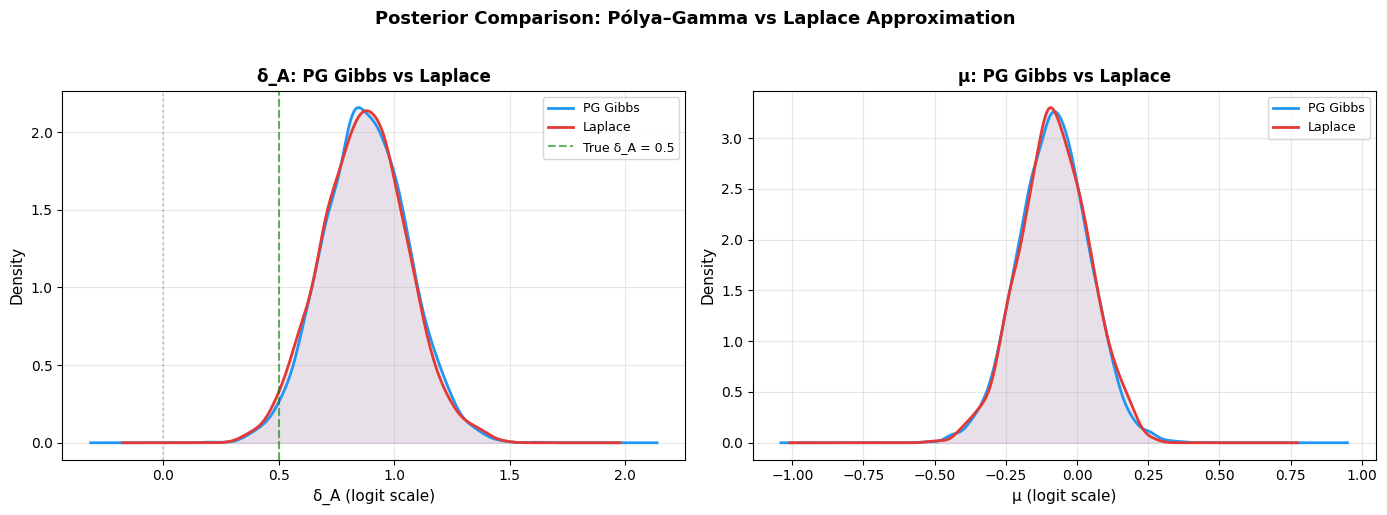

In [35]:
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# δ_A comparison
ax = axes[0]
for samples, label, color in [
    (delta_samples, "PG Gibbs", "#2196F3"),
    (laplace_delta, "Laplace", "#E53935"),
]:
    kde = gaussian_kde(samples)
    x = np.linspace(samples.min() - 0.5, samples.max() + 0.5, 300)
    ax.plot(x, kde(x), linewidth=2, color=color, label=label)
    ax.fill_between(x, kde(x), alpha=0.1, color=color)

ax.axvline(0.5, color="green", ls="--", alpha=0.6, label="True δ_A = 0.5")
ax.axvline(0, color="gray", ls=":", alpha=0.4)
ax.set_xlabel("δ_A (logit scale)", fontsize=11)
ax.set_ylabel("Density", fontsize=11)
ax.set_title("δ_A: PG Gibbs vs Laplace", fontsize=12, fontweight="bold")
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

# μ comparison
ax = axes[1]
for samples, label, color in [
    (mu_samples, "PG Gibbs", "#2196F3"),
    (laplace_mu, "Laplace", "#E53935"),
]:
    kde = gaussian_kde(samples)
    x = np.linspace(samples.min() - 0.5, samples.max() + 0.5, 300)
    ax.plot(x, kde(x), linewidth=2, color=color, label=label)
    ax.fill_between(x, kde(x), alpha=0.1, color=color)

ax.set_xlabel("μ (logit scale)", fontsize=11)
ax.set_ylabel("Density", fontsize=11)
ax.set_title("μ: PG Gibbs vs Laplace", fontsize=12, fontweight="bold")
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

fig.suptitle("Posterior Comparison: Pólya–Gamma vs Laplace Approximation", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
fig.savefig(IMG_DIR / "pg_vs_laplace_posterior_comparison.png", dpi=200, bbox_inches="tight", facecolor="white")
plt.show()

## MCMC diagnostics

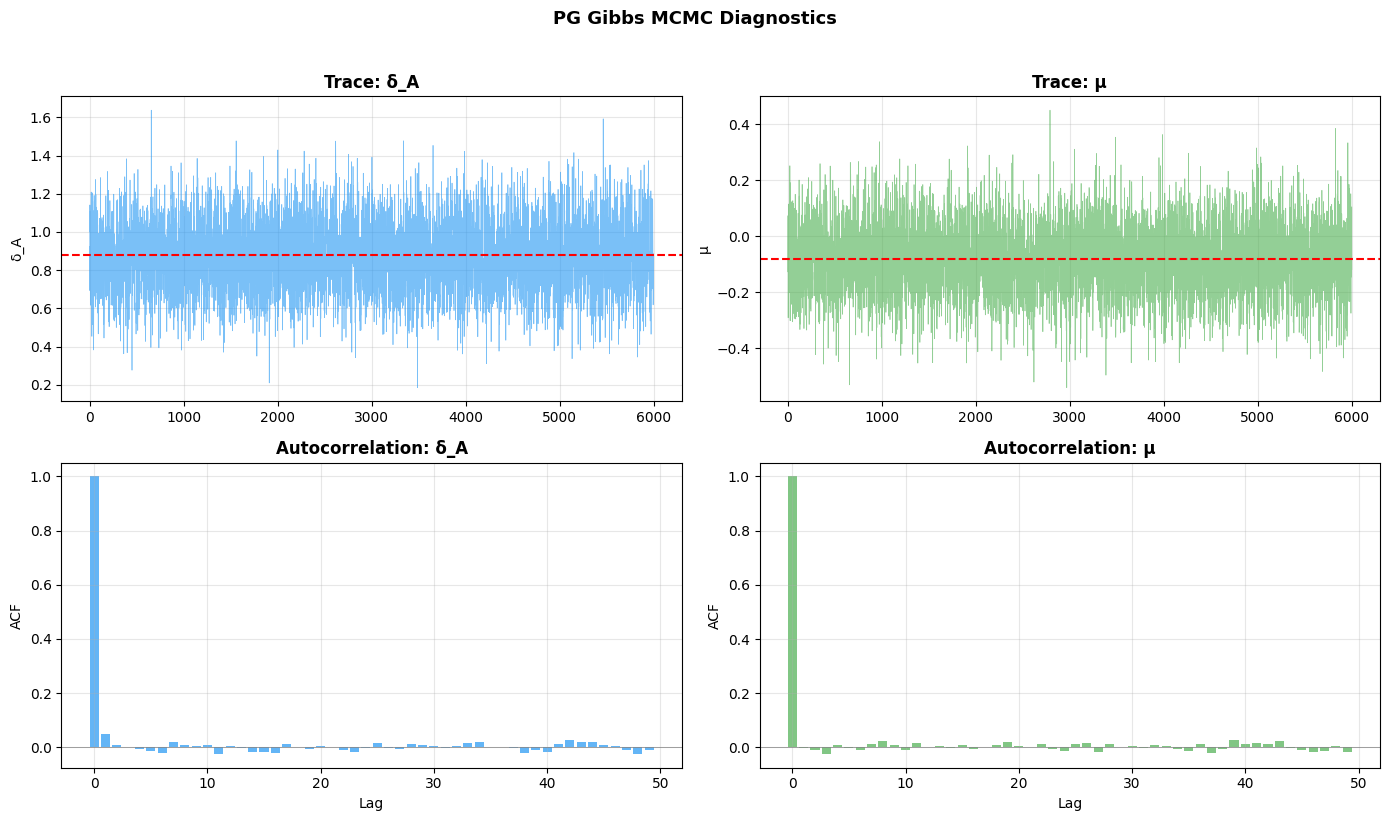

In [36]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# Trace plots
axes[0, 0].plot(delta_samples, alpha=0.6, linewidth=0.5, color="#2196F3")
axes[0, 0].axhline(delta_samples.mean(), color="red", ls="--", lw=1.5)
axes[0, 0].set_ylabel("δ_A")
axes[0, 0].set_title("Trace: δ_A", fontweight="bold")
axes[0, 0].grid(alpha=0.3)

axes[0, 1].plot(mu_samples, alpha=0.6, linewidth=0.5, color="#4CAF50")
axes[0, 1].axhline(mu_samples.mean(), color="red", ls="--", lw=1.5)
axes[0, 1].set_ylabel("μ")
axes[0, 1].set_title("Trace: μ", fontweight="bold")
axes[0, 1].grid(alpha=0.3)

# Autocorrelation
max_lag = 50
for ax, samples, name, color in [
    (axes[1, 0], delta_samples, "δ_A", "#2196F3"),
    (axes[1, 1], mu_samples, "μ", "#4CAF50"),
]:
    centered = samples - samples.mean()
    acf = np.correlate(centered, centered, mode="full")
    acf = acf[len(acf) // 2 :]
    acf /= acf[0]
    ax.bar(range(max_lag), acf[:max_lag], color=color, alpha=0.7)
    ax.axhline(0, color="gray", ls="-", lw=0.5)
    ax.set_xlabel("Lag")
    ax.set_ylabel("ACF")
    ax.set_title(f"Autocorrelation: {name}", fontweight="bold")
    ax.grid(alpha=0.3)

fig.suptitle("PG Gibbs MCMC Diagnostics", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
fig.savefig(IMG_DIR / "mcmc_diagnostics_trace_acf.png", dpi=200, bbox_inches="tight", facecolor="white")
plt.show()

## Savage-Dickey Bayes Factor

We can compute the same Savage-Dickey test using the PG posterior samples:

$$
BF_{01} = \frac{p(\delta_A = 0 \mid D)}{g(0)}
$$

In [37]:
from scipy.stats import norm

# Use decide() for both models
d_laplace = laplace_model.decide()
bf_laplace = d_laplace.bayes_factor

print("Savage-Dickey Bayes Factor comparison")
print("=" * 55)
print(f"{'':20} {'PG Gibbs':>15} {'Laplace':>15}")
print("-" * 55)
print(f"{'Post. density at 0':20} {bf_pg.posterior_density_at_0:>15.4e} {bf_laplace.posterior_density_at_0:>15.4e}")
print(f"{'Prior density at 0':20} {bf_pg.prior_density_at_0:>15.6f} {bf_laplace.prior_density_at_0:>15.6f}")
print(f"{'BF_10':20} {bf_pg.BF_10:>15.2f} {bf_laplace.BF_10:>15.2f}")
print(f"{'log₁₀(BF_10)':20} {np.log10(bf_pg.BF_10):>15.1f} {np.log10(bf_laplace.BF_10):>15.1f}")
print(f"{'BF Decision':20} {bf_pg.decision:>15} {bf_laplace.decision:>15}")
print(f"{'ROPE Decision':20} {d_pg.rope.decision:>15} {d_laplace.rope.decision:>15}")
print("=" * 55)

Savage-Dickey Bayes Factor comparison
                            PG Gibbs         Laplace
-------------------------------------------------------
Post. density at 0        1.1960e-10      3.3642e-17
Prior density at 0          0.398942        0.398942
BF_10                  3335592934.76 11858417005440586.00
log₁₀(BF_10)                     9.5            16.1
BF Decision                Reject H0       Reject H0
ROPE Decision        Reject H0 — A practically better Reject H0 — A practically better


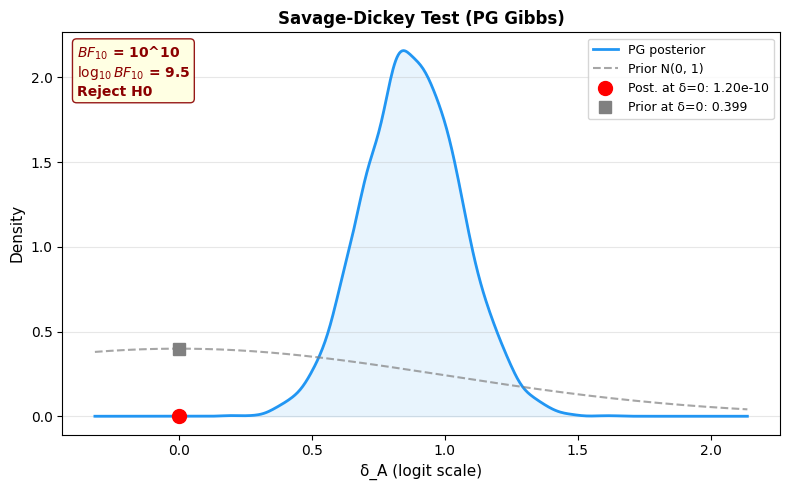

In [38]:
fig, ax = plt.subplots(figsize=(8, 5))

kde_pg = gaussian_kde(delta_samples)
x_grid = np.linspace(delta_samples.min() - 0.5, delta_samples.max() + 0.5, 500)

ax.plot(x_grid, kde_pg(x_grid), color="#2196F3", lw=2, label="PG posterior")
ax.fill_between(x_grid, kde_pg(x_grid), alpha=0.1, color="#2196F3")

prior_density = norm.pdf(x_grid, 0, 1.0)
ax.plot(x_grid, prior_density, color="gray", lw=1.5, ls="--", alpha=0.7, label="Prior N(0, 1)")

ax.plot(
    0,
    bf_pg.posterior_density_at_0,
    "o",
    color="red",
    ms=10,
    zorder=5,
    label=f"Post. at δ=0: {bf_pg.posterior_density_at_0:.2e}",
)
ax.plot(
    0,
    bf_pg.prior_density_at_0,
    "s",
    color="gray",
    ms=8,
    zorder=5,
    label=f"Prior at δ=0: {bf_pg.prior_density_at_0:.3f}",
)

bf10_label = _format_bf(bf_pg.BF_10)
log10_bf = np.log10(bf_pg.BF_10)
ax.text(
    0.02,
    0.97,
    f"$BF_{{10}}$ = {bf10_label}\n$\\log_{{10}}BF_{{10}}$ = {log10_bf:.1f}\n{bf_pg.decision}",
    fontsize=10,
    fontweight="bold",
    color="darkred",
    transform=ax.transAxes,
    verticalalignment="top",
    bbox=dict(boxstyle="round,pad=0.3", facecolor="lightyellow", edgecolor="darkred", alpha=0.9),
)

ax.set_xlabel("δ_A (logit scale)", fontsize=11)
ax.set_ylabel("Density", fontsize=11)
ax.set_title("Savage-Dickey Test (PG Gibbs)", fontsize=12, fontweight="bold")
ax.legend(fontsize=9, loc="upper right")
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
fig.savefig(IMG_DIR / "savage_dickey_pg_gibbs.png", dpi=200, bbox_inches="tight", facecolor="white")
plt.show()

## Posterior predictive check

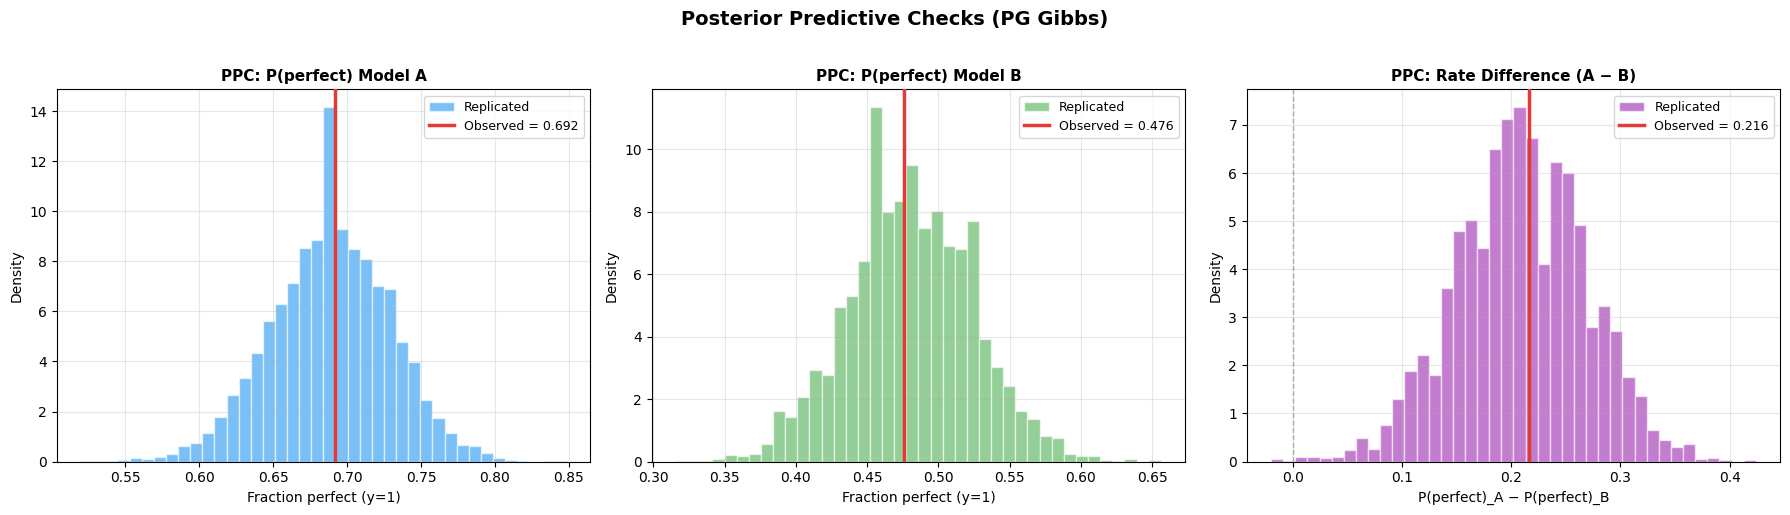

Posterior Predictive p-values (two-sided) — PG Gibbs
Statistic              Observed    p-value     Status
----------------------------------------------------------------------
mean(y_A)                0.6920      0.989         OK
mean(y_B)                0.4760      0.960         OK
mean(y_A-y_B)            0.2160      0.928         OK
std(y_A-y_B)             0.6398      0.129         OK
n_disagree             114.0000      0.147         OK


In [39]:
# ── PPC plots (using class method) ────────────────────────────────────
_show = plt.show
plt.show = lambda: None
pg_model.plot_ppc(seed=42)
plt.savefig(IMG_DIR / "ppc_plots_pg_gibbs.png", dpi=200, bbox_inches="tight", facecolor="white")
plt.show = _show
plt.show()

# ── PPC p-values ─────────────────────────────────────────────────────
print("Posterior Predictive p-values (two-sided) — PG Gibbs")
print("=" * 70)
print(f"{'Statistic':<20} {'Observed':>10} {'p-value':>10} {'Status':>10}")
print("-" * 70)

ppc = pg_model.ppc_pvalues(seed=42)
for stat_name, vals in ppc.items():
    print(f"{stat_name:<20} {vals.observed:>10.4f} {vals.p_value:>10.3f} {vals.status:>10}")

print("=" * 70)

## Unified Decision Rule: `model.decide()`

Run all three decision frameworks (Bayes Factor, Posterior Null, ROPE) in a single call and compare PG Gibbs vs Laplace.

In [40]:
print("Unified Decision — PG Gibbs vs Laplace")
print("=" * 70)

for label, m in [("PG Gibbs", pg_model), ("Laplace", laplace_model)]:
    d = m.decide()

    bf = d.bayes_factor
    pn = d.posterior_null
    rp = d.rope

    print(f"\n{label}:")
    print(f"  Bayes Factor:    BF₁₀ = {bf.BF_10:.2f}  → {bf.decision}")
    print(f"  Posterior Null:   P(H₀|D) = {pn.p_H0:.4f}  → {pn.decision}")
    print(f"  ROPE [{rp.rope_lower:.2f}, {rp.rope_upper:.2f}]:  {rp.decision}  ({rp.pct_in_rope:.1%} in ROPE)")

print("\n" + "=" * 70)
print(f"{'Model':<15} {'BF Decision':>15} {'P(H₀) Decision':>18} {'ROPE Decision':>16}")
print("-" * 70)
for label, m in [("PG Gibbs", pg_model), ("Laplace", laplace_model)]:
    d = m.decide()
    print(f"{label:<15} {d.bayes_factor.decision:>15} {d.posterior_null.decision:>18} {d.rope.decision:>16}")
print("=" * 70)

Unified Decision — PG Gibbs vs Laplace

PG Gibbs:
  Bayes Factor:    BF₁₀ = 3335592934.76  → Reject H0
  Posterior Null:   P(H₀|D) = 0.0000  → Reject H0
  ROPE [-0.02, 0.02]:  Reject H0 — A practically better  (0.0% in ROPE)

Laplace:
  Bayes Factor:    BF₁₀ = 11858417005440586.00  → Reject H0
  Posterior Null:   P(H₀|D) = 0.0000  → Reject H0
  ROPE [-0.02, 0.02]:  Reject H0 — A practically better  (0.0% in ROPE)

Model               BF Decision     P(H₀) Decision    ROPE Decision
----------------------------------------------------------------------
PG Gibbs              Reject H0          Reject H0 Reject H0 — A practically better
Laplace               Reject H0          Reject H0 Reject H0 — A practically better


### Bayes Factor Design Analysis (BFDA) — Sample Size Planning (Paired PG)

For a hypothesised true effect $\Delta = \theta_A - \theta_B$, we simulate many paired
datasets at each sample size and estimate the probability of obtaining *decisive*
evidence via the PG Gibbs + Savage-Dickey framework

In [41]:
import matplotlib.pyplot as plt
import numpy as np

from bayesprop.utils.utils import (
    bfda_power_curve,
    find_n_for_power,
    plot_bfda_power,
    plot_bfda_sensitivity,
)

# ── Use simulated rates as plug-in estimates for the true effect ──────
theta_A_hat = y_A_sim.mean()
theta_B_hat = y_B_sim.mean()

print("Assumed true rates (from simulated data):")
print(f"  θ_A = {theta_A_hat:.3f}")
print(f"  θ_B = {theta_B_hat:.3f}")
print(f"  True Δ = {theta_A_hat - theta_B_hat:.3f} (effect size)")
print()

# ── Compute BFDA power curve (paired PG model) ───────────────────────
sample_sizes = [20, 30, 50, 75, 100, 150, 200, 300, 500]

power_curve_paired = bfda_power_curve(
    theta_A_true=theta_A_hat,
    theta_B_true=theta_B_hat,
    sample_sizes=sample_sizes,
    design="paired",
    decision_rule="bayes_factor",
    bf_threshold=3.0,
    n_sim=200,
    n_iter=1000,
    burn_in=300,
    n_chains=2,
    seed=42,
)

print(f"{'n (per group)':<15} {'P(BF₁₀ > 3)':>12}")
print("-" * 28)
for n, p in power_curve_paired.items():
    print(f"{n:<15} {p:>12.3f}")

n_80 = find_n_for_power(power_curve_paired, 0.80)
print(f"\n→ Estimated n for 80% power: ≈ {n_80:.0f}" if n_80 else "\n→ n for 80% power: > 500")

Assumed true rates (from simulated data):
  θ_A = 0.692
  θ_B = 0.476
  True Δ = 0.216 (effect size)

n (per group)    P(BF₁₀ > 3)
----------------------------
20                     0.045
30                     0.085
50                     0.125
75                     0.190
100                    0.285
150                    0.430
200                    0.690
300                    0.865
500                    0.990

→ Estimated n for 80% power: ≈ 263


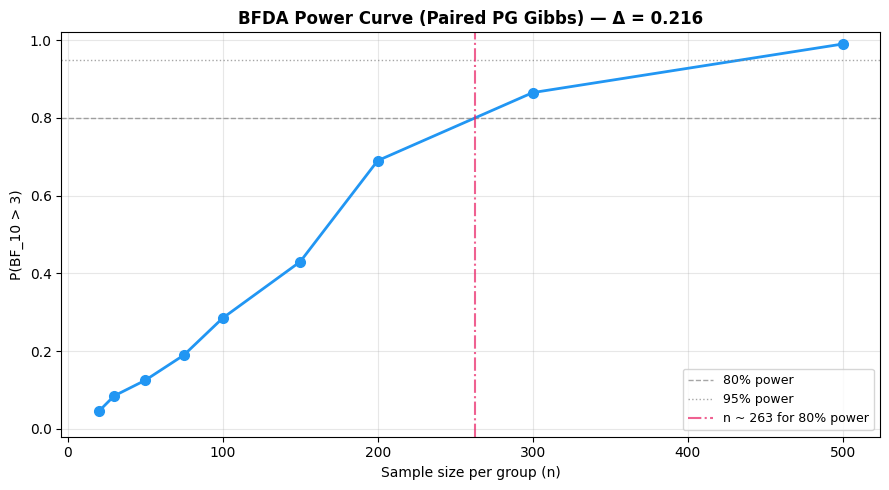

In [42]:
fig = plot_bfda_power(
    power_curve_paired,
    theta_A_hat,
    theta_B_hat,
    title=f"BFDA Power Curve (Paired PG Gibbs) — Δ = {theta_A_hat - theta_B_hat:.3f}",
)
fig.savefig(IMG_DIR / "bfda_power_curve_paired_pg.png", dpi=200, bbox_inches="tight", facecolor="white")
plt.show()

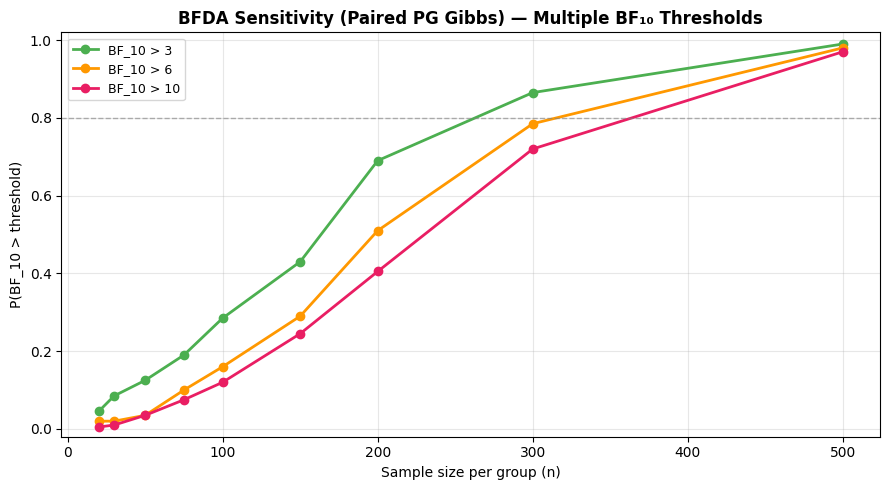

In [43]:
fig = plot_bfda_sensitivity(
    theta_A_true=theta_A_hat,
    theta_B_true=theta_B_hat,
    sample_sizes=sample_sizes,
    thresholds=[3.0, 6.0, 10.0],
    n_sim=200,
    seed=42,
    design="paired",
    title="BFDA Sensitivity (Paired PG Gibbs) — Multiple BF₁₀ Thresholds",
)
fig.savefig(IMG_DIR / "bfda_sensitivity_pg_gibbs.png", dpi=200, bbox_inches="tight", facecolor="white")
plt.show()